This notebook code helps you:
* Load a brain Z-stack (from many .tif slices)
* Create max intensity projections for green and red
* Build ONE grayscale registration image
* Draw ROI regions (once)
* Save those ROI masks permanently for future brains

In [653]:
# Have to run everytime to import everything
# If you ever need to add more imports, add them here to keep everything clean and organized

import os
import re
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import pandas as pd
import IPython as Ip

from pathlib import Path
from matplotlib.path import Path as MplPath
from matplotlib.widgets import PolygonSelector
from scipy.ndimage import rotate, center_of_mass
from skimage.registration import phase_cross_correlation
from skimage.transform import EuclideanTransform, warp
from skimage.transform import warp, AffineTransform, resize
from skimage.filters import sobel
from scipy.ndimage import gaussian_filter, binary_fill_holes
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops
from skimage.registration import phase_cross_correlation
from skimage.transform import rotate
from scipy.ndimage import rotate
from tifffile import imread
from IPython.display import display


In [654]:
# Have to run this everytime
# If you need to change ROIs (which ideally you shouldn't), change them here as the code is written to loop through these names and save things based on these names and will overwrite.

# ----------------------------
# REQUIRED: Channel convention
# ----------------------------
# Hard-code based on your lab's file convention:
# C002 = green channel slices
# C003 = red channel slices
GREEN_C = 2
RED_C   = 3

ROI_NAMES = [
    "registration_core",
    "PI",
    "MB_left",
    "MB_right",
    "CX",
    "AL_left",
    "AL_right",
    "SEG"
    # add more later if you want
]


# Paths for all the data and results
# Change as needed based on where things are being stored

PROJECT_ROOT = Path(".")  # because notebook is already in "crocker lab"

DATA_DIR = PROJECT_ROOT / "data"
TEMPLATE_BRAIN_FOLDER = DATA_DIR / "template_brain"
BRAINS_DIR = DATA_DIR / "brains"

ROI_SAVE_DIR = PROJECT_ROOT / "roi_masks"
TEMPLATE_SAVE_DIR = PROJECT_ROOT / "template_data"
RESULTS_DIR = PROJECT_ROOT / "results"

# Make sure folders exist
ROI_SAVE_DIR.mkdir(exist_ok=True)
TEMPLATE_SAVE_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)



Template shape: (827, 827)
Registration core mask shape: (827, 827)
Resized mask shape: (827, 827)
Resized mask min/max: False True
Using test brain: Draper_F_PiezoModerate_48h_02_20x.tif.frames
Green files found: 34
Draper_F_PiezoModerate_48h_02_20x_C002Z001.tif
Draper_F_PiezoModerate_48h_02_20x_C002Z002.tif
Draper_F_PiezoModerate_48h_02_20x_C002Z003.tif
Draper_F_PiezoModerate_48h_02_20x_C002Z004.tif
Draper_F_PiezoModerate_48h_02_20x_C002Z005.tif
Red files found: 34
Draper_F_PiezoModerate_48h_02_20x_C003Z001.tif
Draper_F_PiezoModerate_48h_02_20x_C003Z002.tif
Draper_F_PiezoModerate_48h_02_20x_C003Z003.tif
Draper_F_PiezoModerate_48h_02_20x_C003Z004.tif
Draper_F_PiezoModerate_48h_02_20x_C003Z005.tif
Channel C002 files found: 34
Draper_F_PiezoModerate_48h_02_20x_C002Z001.tif: shape (1024, 1024), min 0.0, max 44.0
Draper_F_PiezoModerate_48h_02_20x_C002Z002.tif: shape (1024, 1024), min 0.0, max 31.0
Draper_F_PiezoModerate_48h_02_20x_C002Z003.tif: shape (1024, 1024), min 0.0, max 20.0
Draper

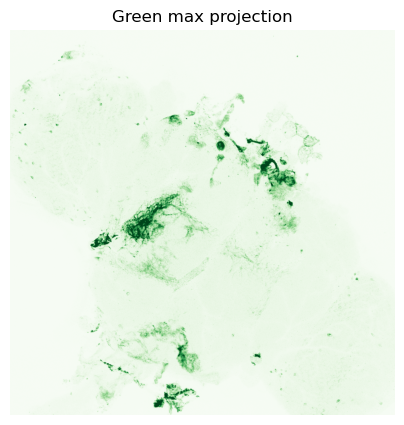

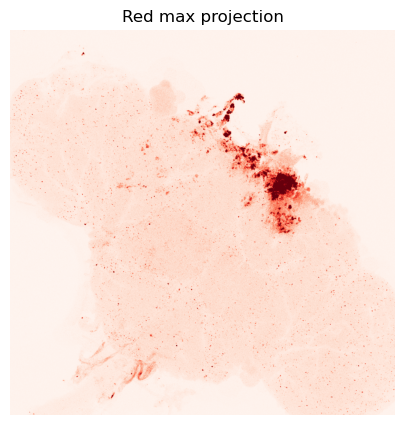

In [655]:
# Have to run this every time to load the template and registration core mask

# Load template registration image (already created)
template_reg = np.load("template_data/template_reg_img.npy")

# Load registration core mask
reg_mask = np.load("roi_masks/registration_core.npy")

#avoiding the result as zeros:
reg_mask_resized = resize(
    reg_mask,
    template_reg.shape,
    preserve_range=True,   # keep 0/1 values
    anti_aliasing=False
)

print("Template shape:", template_reg.shape)
print("Registration core mask shape:", reg_mask.shape)
print("Resized mask shape:", reg_mask_resized.shape)
print("Resized mask min/max:", reg_mask_resized.min(), reg_mask_resized.max())

#testing
def extract_z(fname):
    """Extract Z index from filename like ..._C002Z015.tif"""
    m = re.search(r"Z(\d+)", fname)
    return int(m.group(1)) if m else None

def load_stack_debug(folder, channel):
    """Load stack for a given channel and print debug info per slice."""
    files = sorted(folder.glob(f"*C{channel:03d}Z*.tif"), key=lambda f: extract_z(f.name))
    if not files:
        raise FileNotFoundError(f"No files for channel C{channel:03d}")
    
    slices = []
    print(f"Channel C{channel:03d} files found:", len(files))
    for f in files:
        img = imread(str(f))
        if img.ndim == 3:
            if channel == GREEN_C:
                img = img[..., 1]  # green is in plane 1
            elif channel == RED_C:
                img = img[..., 0]  # red is in plane 0
            else:
                img = img[..., 0]  # default, just in case
        img = img.astype(np.float32)
        slices.append(img)
        print(f"{f.name}: shape {img.shape}, min {img.min()}, max {img.max()}")
    stack = np.stack(slices, axis=0)
    print(f"C{channel:03d} stack shape: {stack.shape}, min/max: {stack.min()}/{stack.max()}")
    return stack


TEST_BRAIN_DIR = Path("/Users/gabrielacmclemente/Desktop/PythonProcessing/Draper_F_PiezoModerate_48h_02_20x.tif.frames")
print("Using test brain:", TEST_BRAIN_DIR.name)

green_files = sorted(TEST_BRAIN_DIR.glob("*C002Z*.tif"))
red_files   = sorted(TEST_BRAIN_DIR.glob("*C003Z*.tif"))

print("Green files found:", len(green_files))
for f in green_files[:5]:
    print(f.name)

print("Red files found:", len(red_files))
for f in red_files[:5]:
    print(f.name)

#new tests part 2
green_stack = load_stack_debug(TEST_BRAIN_DIR, GREEN_C)
red_stack   = load_stack_debug(TEST_BRAIN_DIR, RED_C)

# Max projection
green_proj = green_stack.max(axis=0)
red_proj   = red_stack.max(axis=0)

print("Green max projection min/max:", green_proj.min(), green_proj.max())
print("Red max projection min/max:", red_proj.min(), red_proj.max())

#additional stuff
f = green_files[0]
img = tiff.imread(str(f))
print(img.shape, img.min(), img.max(), img.dtype)

if img.ndim == 3:
    for i in range(img.shape[2]):
        print(f"Channel {i} min/max:", img[...,i].min(), img[...,i].max())

# Quick plot to visually confirm
plt.figure(figsize=(5,5))
plt.imshow(green_proj, cmap="Greens")
plt.title("Green max projection")
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(red_proj, cmap="Reds")
plt.title("Red max projection")
plt.axis("off")
plt.show()

In [656]:
def normalize01(img):
    img = img.astype(np.float32)
    img = img - img.min()
    return img / (img.max() + 1e-8)

def largest_component(mask):
    lab = label(mask)
    if lab.max() == 0:
        return mask
    regions = regionprops(lab)
    largest = max(regions, key=lambda r: r.area)
    return lab == largest.label

def make_silhouette(img, blur_sigma=2, min_size=2000):
    """Return a clean binary brain silhouette."""
    x = normalize01(img)
    x = gaussian_filter(x, blur_sigma)

    t = threshold_otsu(x)
    mask = x > t

    mask = remove_small_objects(mask, min_size=min_size)
    mask = binary_fill_holes(mask)
    mask = largest_component(mask)

    return mask.astype(bool)

def pca_angle_from_mask(mask):
    """
    Returns principal axis angle in degrees.
    Angle is measured w.r.t. x-axis (cols), standard math convention.
    """
    ys, xs = np.nonzero(mask)
    if len(xs) < 50:
        return 0.0

    x = xs - xs.mean()
    y = ys - ys.mean()
    coords = np.vstack([x, y])

    cov = np.cov(coords)
    vals, vecs = np.linalg.eig(cov)

    # principal eigenvector
    v = vecs[:, np.argmax(vals)]
    angle = np.degrees(np.arctan2(v[1], v[0]))  # arctan2(y, x)
    return float(angle)


Green stack: (34, 1024, 1024)
Red stack: (34, 1024, 1024)


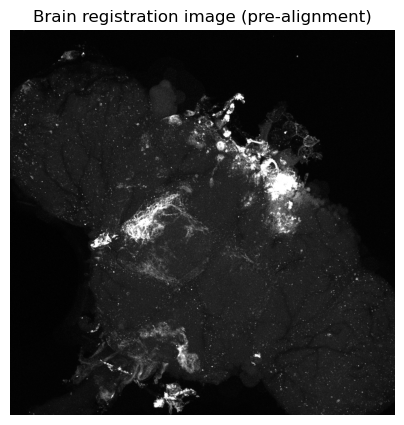

In [657]:
# Helper function to adjust size of images if neeeded
def match_shape_by_crop_or_pad(img, target_shape):
    h, w = img.shape
    th, tw = target_shape

    # Start with the original image
    out = img.copy()

    # --- Crop if too large ---
    if h > th:
        start_y = (h - th) // 2
        out = out[start_y:start_y+th, :]
    if w > tw:
        start_x = (w - tw) // 2
        out = out[:, start_x:start_x+tw]

    # --- Pad if too small ---
    h2, w2 = out.shape
    pad_y = max(th - h2, 0)
    pad_x = max(tw - w2, 0)

    pad_top = pad_y // 2
    pad_bottom = pad_y - pad_top
    pad_left = pad_x // 2
    pad_right = pad_x - pad_left

    out = np.pad(
        out,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=0
    )

    return out

# Helper function to load image stacks
def extract_z(fname):
    m = re.search(r"Z(\d+)", fname)
    return int(m.group(1)) if m else None

#Helper function to load image stacks
def load_stack(folder, channel):
    files = sorted(
        folder.glob(f"*C{channel:03d}Z*.tif"),
        key=lambda f: extract_z(f.name)
    )
    if not files:
        raise FileNotFoundError(f"No files for channel C{channel:03d}")

    stack = []
    for f in files:
        img = tiff.imread(str(f)).astype(np.float32)
        if img.ndim == 3:
            # Use correct plane based on channel
            if channel == GREEN_C:  # green channel
                img = img[..., 1]
            elif channel == RED_C:  # red channel
                img = img[..., 0]
            else:
                img = img[..., 0]  # default fallback
        stack.append(img)

    return np.stack(stack, axis=0)

def load_stack_with_debug(folder, channel):
    files = sorted(folder.glob(f"*C{channel:03d}Z*.tif"), key=lambda f: extract_z(f.name))
    if not files:
        raise FileNotFoundError(f"No files for channel C{channel:03d}")

    slices = []
    maxes = []

    for f in files:
        img = tiff.imread(str(f))
        if img.ndim == 3:
            img = img[..., 0]
        img = img.astype(np.float32)

        slices.append(img)
        maxes.append(float(img.max()))

    stack = np.stack(slices, axis=0)

    print(f"C{channel:03d} loaded slices:", len(files))
    print(f"  slice max range: {min(maxes)} .. {max(maxes)}")
    print(f"  stack min/max: {float(stack.min())} .. {float(stack.max())}")

    return stack, files

# Load green and red stacks
green_stack = load_stack(TEST_BRAIN_DIR, channel=2)
red_stack   = load_stack(TEST_BRAIN_DIR, channel=3)

print("Green stack:", green_stack.shape)
print("Red stack:", red_stack.shape)

# Build brain registration image (pre-alignment)
def max_project(stack):
    return stack.max(axis=0)

def normalize(img):
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

green_proj = max_project(green_stack)
red_proj   = max_project(red_stack)

brain_reg_img = np.maximum(
    normalize(green_proj),
    normalize(red_proj)
)


plt.figure(figsize=(5,5))
plt.imshow(brain_reg_img, cmap="gray")
plt.title("Brain registration image (pre-alignment)")
plt.axis("off")
plt.show()


In [658]:
# Make brain registration image the same shape as the template
brain_reg_matched = match_shape_by_crop_or_pad(
    brain_reg_img,
    template_reg.shape
)

print("Brain reg matched shape:", brain_reg_matched.shape)
print("Template shape:", template_reg.shape)


Brain reg matched shape: (827, 827)
Template shape: (827, 827)


In [659]:

# Apply Gaussian smoothing and multiply by resized mask
template_for_sil = gaussian_filter(normalize01(template_reg), 2) * reg_mask_resized
brain_for_sil = gaussian_filter(normalize01(brain_reg_matched), 2) * reg_mask_resized  #change 1 right here! 

# Make silhouettes for PCA and center of mass calculations
template_sil = make_silhouette(template_for_sil, blur_sigma=1.5, min_size=1000)
brain_sil    = make_silhouette(brain_for_sil,    blur_sigma=1.5, min_size=1000)

# Compute PCA angles
template_angle = pca_angle_from_mask(template_sil)
brain_angle    = pca_angle_from_mask(brain_sil)

coarse_angle = template_angle - brain_angle

# Compute anatomical centers
template_center = center_of_mass(template_sil)
brain_center    = center_of_mass(brain_sil)

print("Template center:", template_center)
print("Brain center:", brain_center)

# Build proper rigid transform

# Translation that moves brain center to origin
t1 = EuclideanTransform(
    translation=(-brain_center[1], -brain_center[0])
)

# Rotation around origin
r = EuclideanTransform(rotation=np.deg2rad(coarse_angle))

# Translation that moves origin to template center
t2 = EuclideanTransform(
    translation=(template_center[1], template_center[0])
)

# Compose transforms
tform_total = t2 + r + t1

# Apply warp to aligned brain
brain_reg_aligned = warp(
    brain_reg_matched.astype(float),
    tform_total,
    output_shape=template_reg.shape,
    preserve_range=True,
    mode="constant",
    cval=0
)

print("Template PCA angle:", template_angle)
print("Brain PCA angle:", brain_angle)
print("Coarse angle (deg):", coarse_angle)

Template center: (np.float64(510.3743795102824), np.float64(374.88845784841277))
Brain center: (np.float64(294.9934465419174), np.float64(586.8711153243755))
Template PCA angle: -28.90981048438458
Brain PCA angle: -126.55813330173173
Coarse angle (deg): 97.64832281734715


/var/folders/xs/8gxb3_jd60dcg5yk6zhkh1t00000gn/T/ipykernel_45597/462530167.py:22: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_size)


Measuring Intensities in ROIs

In [660]:
def show_stretched(img, title=""):
    x = img.astype(np.float32)
    lo, hi = np.percentile(x, (1, 99.5))  # robust stretch
    if hi <= lo:
        lo, hi = x.min(), x.max() + 1e-8
    x = np.clip((x - lo) / (hi - lo), 0, 1)

    plt.figure(figsize=(5,5))
    plt.imshow(x, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

In [661]:
green_proj_matched = match_shape_by_crop_or_pad(green_proj, template_reg.shape)
red_proj_matched   = match_shape_by_crop_or_pad(red_proj, template_reg.shape)

brain_reg_aligned = warp(
    brain_reg_matched.astype(float),
    tform_total,
    output_shape=template_reg.shape,
    preserve_range=True,
    mode="edge",
    cval=0
)

green_aligned = warp(
    green_proj_matched,
    tform_total,
    output_shape=template_reg.shape,
    preserve_range=True,
    mode='edge',
    cval=0
)
red_aligned = warp(
    red_proj_matched,
    tform_total,
    output_shape=template_reg.shape,
    preserve_range=True,
    mode='edge',
    cval=0
)

green_aligned = normalize01(green_aligned)
red_aligned = normalize01(red_aligned)

aligned_masks = {}
for roi_file in sorted(ROI_SAVE_DIR.glob("*.npy")):
    name = roi_file.stem
    mask = np.load(roi_file)
    mask_resized = resize(mask.astype(float), green_aligned.shape, order=0, preserve_range=True, anti_aliasing=False) > 0.5
    aligned_masks[name] = mask_resized


print("Green Before warp:", green_proj_matched.min(), green_proj_matched.max())
print("Red Before warp:", red_proj_matched.min(), red_proj_matched.max())
print("green_aligned min/max:", float(green_aligned.min()), float(green_aligned.max()))
print("red_aligned min/max:", float(red_aligned.min()), float(red_aligned.max()))
green_vals = green_aligned[mask_resized]
red_vals   = red_aligned[mask_resized]
print(green_vals.max(), red_vals.max())

Green Before warp: 1.0 255.0
Red Before warp: 1.0 255.0
green_aligned min/max: 0.0 1.0
red_aligned min/max: 0.0 1.0
0.47977212 1.0


In [662]:
rows = []
for name, mask in aligned_masks.items():
    if name == "registration_core":
        continue
    if mask.sum() == 0:
        green_max = red_max = ratio = np.nan
    else:
        green_vals = green_aligned[mask]
        red_vals   = red_aligned[mask]
        green_max = float(green_vals.max()) if green_vals.size else np.nan
        red_max   = float(red_vals.max()) if red_vals.size else np.nan
        ratio = green_max / red_max if red_max > 0 else np.nan

    rows.append({
        "roi": name,
        "green_max": green_max,
        "red_max": red_max,
        "green_red_ratio": ratio
    })

df = pd.DataFrame(rows).sort_values("roi")
df
display(df)  



,roi,green_max,red_max,green_red_ratio
0,AL_left,0.452586,0.577618,0.783539
1,AL_right,0.199801,0.238994,0.836009
2,CX,0.453340,0.998600,0.453976
3,MB_left,0.453340,0.992415,0.456805
4,MB_right,0.079577,0.112350,0.708296
5,PI,0.385719,0.408310,0.944672
6,SEG,0.478307,1.000000,0.478307


ONLY IF YOU NEED TO CHANGE ROIS
* Please don't edit unless needed and make sure you are only changing what you need. It will overwrite what has already been done *

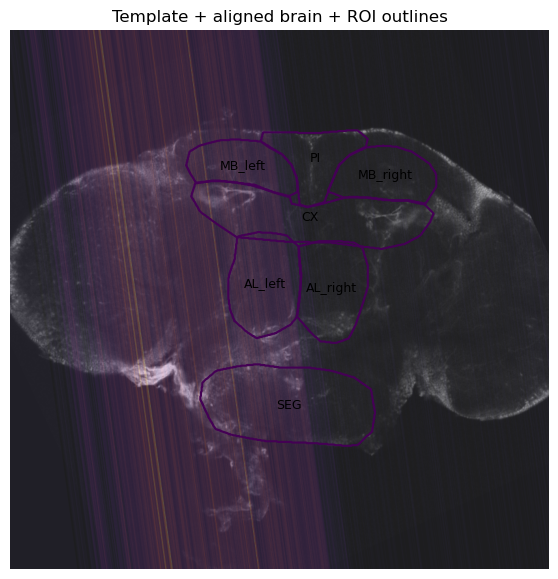

In [663]:
ROI_SAVE_DIR = Path("roi_masks")

# Load all ROI masks you saved (skip registration_core if you want)
roi_files = sorted(ROI_SAVE_DIR.glob("*.npy"))
roi_files = [f for f in roi_files if f.stem != "registration_core"]

plt.figure(figsize=(7,7))
plt.imshow(template_reg, cmap="gray", alpha=0.85)
plt.imshow(brain_reg_aligned, cmap="magma", alpha=0.25)

# Draw mask outlines
for f in roi_files:
    mask = np.load(f)
    # Contour draws an outline at the boundary
    plt.contour(mask.astype(float), levels=[0.5], linewidths=1.5)
    # Optional: label each ROI near its centroid
    ys, xs = np.where(mask)
    if len(xs) > 0:
        plt.text(xs.mean(), ys.mean(), f.stem, fontsize=9, ha="center", va="center")

plt.title("Template + aligned brain + ROI outlines")
plt.axis("off")
plt.show()

Code for drawing ROIs so don't use unless you need to change ROIs and make sure to change the ROI_Names at the top, so you don't overwrite masks you don't want to

Loaded existing masks: ['AL_right', 'registration_core', 'SEG', 'MB_right', 'AL_left', 'CX', 'PI', 'MB_left']


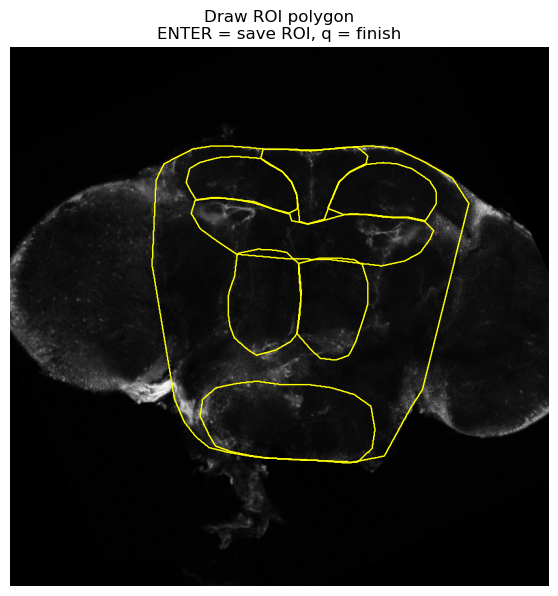

New ROIs collected: []


In [664]:
# ---------------------------------------
# Load existing ROI masks (if any)
# ---------------------------------------
ROI_SAVE_DIR = Path("roi_masks")
existing_masks = {}

if ROI_SAVE_DIR.exists():
    for p in ROI_SAVE_DIR.glob("*.npy"):
        existing_masks[p.stem] = np.load(p)

print("Loaded existing masks:", list(existing_masks.keys()))

# ---------------------------------------
# ROI Drawer class (STABLE VERSION)
# ---------------------------------------
class ROIDrawer:
    def __init__(self, base_image, roi_names, existing_masks=None):
        self.base_image = base_image
        self.roi_names = roi_names
        self.current_index = 0
        self.current_verts = None
        self.rois = []

        self.fig, self.ax = plt.subplots(figsize=(7, 7))
        self.ax.imshow(base_image, cmap="gray")
        self.ax.set_title(
            "Draw ROI polygon\n"
            "ENTER = save ROI, q = finish"
        )
        self.ax.axis("off")

        # Overlay existing masks (yellow outlines)
        if existing_masks:
            for name, mask in existing_masks.items():
                self.ax.contour(mask, colors="yellow", linewidths=1)

        self.selector = PolygonSelector(self.ax, self.on_select)
        self.fig.canvas.mpl_connect("key_press_event", self.on_key)

    def on_select(self, verts):
        self.current_verts = verts

    def on_key(self, event):
        if event.key == "enter":
            if self.current_verts is None or len(self.current_verts) < 3:
                print("ROI not valid.")
                return

            if self.current_index >= len(self.roi_names):
                print("No more ROI names defined.")
                return

            roi_name = self.roi_names[self.current_index]
            self.current_index += 1

            self.rois.append((roi_name, self.current_verts))
            print(f"Saved ROI: {roi_name}")

            # Draw outline of saved ROI
            xs = [p[0] for p in self.current_verts] + [self.current_verts[0][0]]
            ys = [p[1] for p in self.current_verts] + [self.current_verts[0][1]]
            self.ax.plot(xs, ys, linewidth=2)
            self.fig.canvas.draw_idle()

            # Clear selector state (NO reset/recreate)
            self.current_verts = None
            self.selector._xys = []
            self.selector._selection_completed = False

        elif event.key == "q":
            plt.close(self.fig)

    def get_rois(self):
        plt.show()
        return self.rois


drawer = ROIDrawer(
    template_reg,
    ROI_NAMES,
    existing_masks=existing_masks
)

roi_list = drawer.get_rois()

print("New ROIs collected:", [name for name, _ in roi_list])


In [665]:
ROI_SAVE_DIR = Path("roi_masks")
ROI_SAVE_DIR.mkdir(exist_ok=True)

def polygon_to_mask(image_shape, verts):
    h, w = image_shape
    y, x = np.mgrid[:h, :w]
    points = np.vstack((x.ravel(), y.ravel())).T
    mask = MplPath(verts).contains_points(points).reshape(h, w)
    return mask

for roi_name, verts in roi_list:
    mask = polygon_to_mask(template_reg.shape, verts)
    np.save(ROI_SAVE_DIR / f"{roi_name}.npy", mask)
    print(f"Saved mask: {roi_name}")

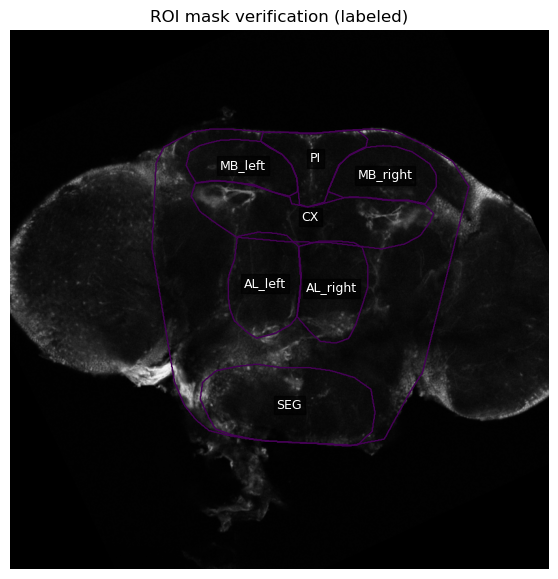

In [666]:
# Checking the ROIs that were drawn and saved

plt.figure(figsize=(7, 7))
plt.imshow(template_reg, cmap="gray")
plt.axis("off")

for roi_file in sorted(ROI_SAVE_DIR.glob("*.npy")):
    roi_name = roi_file.stem
    
    mask = np.load(roi_file)

    # draw contour
    plt.contour(mask, linewidths=1)

    if roi_name == "registration_core":
        continue   # skip labeling this one as it covers a bunch of others

    # label at center of mass
    cy, cx = center_of_mass(mask)
    if not np.isnan(cx) and not np.isnan(cy):
        plt.text(
            cx,
            cy,
            roi_name,
            color="white",
            fontsize=9,
            ha="center",
            va="center",
            bbox=dict(facecolor="black", alpha=0.6, pad=2)
        )

plt.title("ROI mask verification (labeled)")
plt.show()
